In [1]:
import math
import copy
from datetime import datetime
from math import pi
import numpy as np
import pypulseq as pp
import matplotlib.pyplot as plt
from types import SimpleNamespace

# Setup BART toolbox

In [2]:
#%env TOOLBOX_PATH=/Users/aurelien/Documents/Dev/mriSoft/bart/
#%run -i '/Users/aurelien/Documents/Dev/mriSoft/bart/startup.py'

In [3]:
#import bart
#bart.bart(0,"version")

# System limits

In [4]:
# set system limits
system = pp.Opts(
    max_grad=28,
    grad_unit="mT/m",
    max_slew=180, # 90% de 188 T/(m*s)
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6
)

In [5]:
version_sequence = "v1.2.1"
# --------------Paramètres important--------------
fov = np.array([256, 256, 256]) * 1e-3  # Define FOV (m)
N = 128 # size of the reconstruction matrix
alpha=10                     # flip angle
TR = 5e-3                      # TR
nProj= 10000                        # number of radial spokes
reord_traj = "standard" # "standard" / "golden" / "segment"
SGPoints = 0
nSeg = 1# number of segment nProj/nSeg must be an int

# --------------Paramètres divers--------------
threeD = True
riseT = 0.3e-3 #second -> 300us
# attention le dwell time doit être un multiple de 100ns
dwell = 10e-6
nDummy=100                      # number of dummy scans
rf_len = 0.05e-3 # second 
rf_spoiling_inc = 117 # RF spoiling increment
ro_spoil = 3  # Additional k-max excursion for RO spoiling
ro_os = 1  # Readout oversampling

In [6]:
res = fov[0]/N
delta_k = 1 / fov

# --- variable calculé à partir des valeurs
# number of sampled in readout to reach effective resolution
Ns = fov[0]/(2*res) + riseT/(2*dwell)
ro_dur =  dwell * Ns # seconde  
Ns


np.float64(79.0)

# Create RF object

In [7]:
rf = pp.make_block_pulse(
    flip_angle=alpha*pi/180,
    duration=rf_len,
    system=system);


/tmp/ipykernel_1457208/3028051621.py:1: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf = pp.make_block_pulse(


# Create gradient and adc objects

In [8]:

adc = pp.make_adc(
    num_samples=Ns+SGPoints,
    duration=(Ns+SGPoints)*dwell,
    delay=0.0,
    system=system,
)

# gradient

gro = pp.make_trapezoid(
    channel="x",
    amplitude=1/(fov[0]*dwell),
    rise_time = riseT,
    flat_time=dwell*Ns-riseT,
    system=system
)

# split at the end of adc
gro_split_rise,gro_split_flat,_ = pp.split_gradient(gro)
gro_sum = pp.add_gradients([gro_split_rise,gro_split_flat],
                           system=system)

gro_sum

/tmp/ipykernel_1457208/3264049074.py:1: UserWarning: Specified ADC delay 0.00 us is less than the dead time 10 us. Delay was increased to the dead time.
  adc = pp.make_adc(


namespace(type='grad',
          channel='x',
          waveform=array([     0., 390625., 390625.]),
          delay=0.0,
          tt=array([0.     , 0.0003 , 0.00079]),
          shape_dur=np.float64(0.0007900000000000001),
          area=np.float64(250.00000000000003),
          first=np.float64(0.0),
          last=np.float64(390625.0))

In [9]:
# spoil
gspoil = pp.make_trapezoid(
    channel="x",
    area =  2 * N * delta_k[0],
    system=system
)
gspoil

g_spoil_opt,a,b = pp.make_extended_trapezoid_area(
  channel="x",
  grad_start = gro.amplitude,
  grad_end = 0,
  area=2 * N * delta_k[0],
  system=system)

g_spoil_opt.delay=gro_sum.shape_dur

In [10]:
# combine gradients
g_tot = pp.add_gradients([gro_sum,g_spoil_opt],system=system)
g_tot


namespace(type='grad',
          channel='x',
          waveform=array([      0.,  390625.,  390625., 1171875., 1171875.,       0.]),
          delay=0.0,
          tt=array([0.     , 0.0003 , 0.00079, 0.0009 , 0.0016 , 0.00176]),
          shape_dur=np.float64(0.0017600000000000003),
          area=np.float64(1250.0000000000002),
          first=np.float64(0.0),
          last=np.float64(0.0))

In [11]:
# add SG delay
g_tot.delay = SGPoints*dwell

In [12]:
# Delay_TR
delay_TR = TR - (pp.calc_duration(rf)+
                 pp.calc_duration(g_tot))

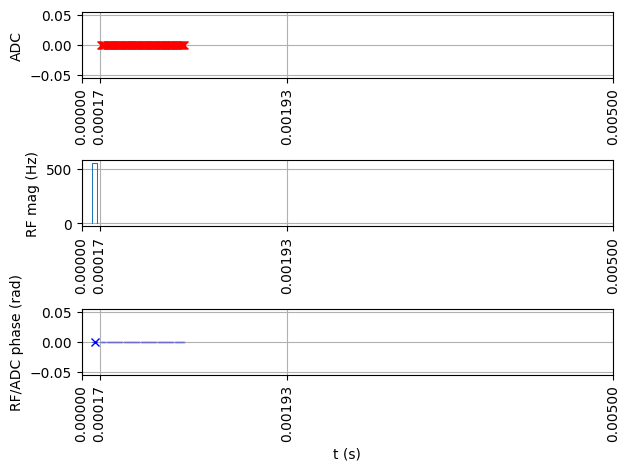

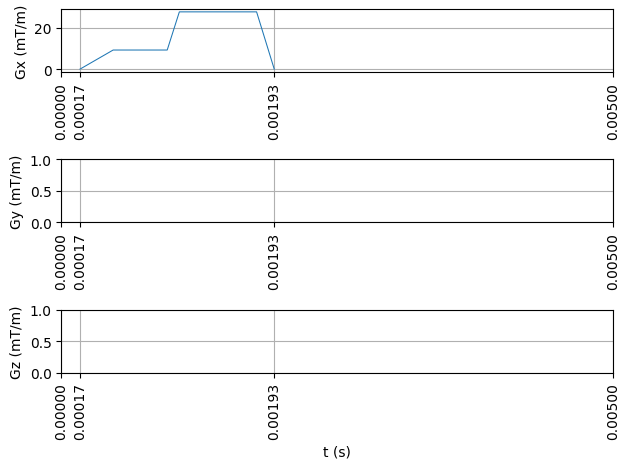

In [13]:
seq=pp.Sequence()

seq.add_block(rf)
seq.add_block(adc,g_tot)
seq.add_block(pp.make_delay(delay_TR))
seq.plot(grad_disp="mT/m",show_blocks=True,time_disp="s",label="SET,PAR")

# Define angle
1. Uniform angle from `Saff EB, Kuijlaars ABJ. Distributing many points on a sphere. The Mathematical Intelligencer. 1997;19(1):5-11. doi:10.1007/BF03024331`

In [14]:
scale_x = np.zeros((nProj),dtype=float)
scale_y = np.zeros((nProj),dtype=float)
scale_z = np.zeros((nProj),dtype=float)

if threeD:
  beta1 = 0
  beta = 0
  for ipro in range(nProj):
    hn = -1 + (2*ipro)/(nProj-1)
    alpha = np.arccos(hn)
    if ipro == 0 or ipro == (nProj-1):
      beta = 0
    else:
      beta = np.mod(beta1 + 3.6/np.sqrt(nProj*(1-hn*hn)),2*pi)

    beta1=beta
    scale_x[ipro] = np.cos(beta)*np.sin(alpha)
    scale_y[ipro] = np.sin(beta)*np.sin(alpha)
    scale_z[ipro] = np.cos(alpha)


else:
  phi = np.linspace(0,2*pi,nProj)

  for ipro in range(nProj): # 2D
    scale_x[ipro] = np.cos(phi[ipro])
    scale_y[ipro] = np.sin(phi[ipro])
    scale_z[ipro] = 0

scale_x

array([ 1.22464680e-16, -4.54404205e-03, -2.82160682e-02, ...,
        1.90787690e-02,  1.13128220e-02,  0.00000000e+00])

2. reorder with 1D golden angle

In [15]:
if reord_traj == "golden":
    print("reorder : gold")
    scale_x_tmp = scale_x.copy()
    scale_y_tmp = scale_y.copy()
    scale_z_tmp = scale_z.copy()

    index = 0
    for ipro in range(nProj): # 2D
        if ipro == (nProj-1):
            index = 0
        else:
            index = int(np.ceil(np.mod((nProj-(ipro+1))*((ipro+1)*(np.sqrt(5.0)-1) / 3.0),nProj-(ipro+1))))

        scale_x[ipro] = scale_x_tmp[index]
        scale_y[ipro] = scale_y_tmp[index]
        scale_z[ipro] = scale_z_tmp[index]

        np.delete(scale_x_tmp,index)
        np.delete(scale_y_tmp,index)
        np.delete(scale_z_tmp,index)
elif reord_traj == "segment":
    print("reorder : segment")
    scale_x_tmp = scale_x.copy()
    scale_y_tmp = scale_y.copy()
    scale_z_tmp = scale_z.copy()

    index = 0
    for seg in range(int(nProj/nSeg)): # 2D
        #print(seg)
        for ipro in np.arange(seg,nProj,int(nProj/nSeg)): # 2D
            #print(ipro)
            scale_x[index] = scale_x_tmp[ipro]
            scale_y[index] = scale_y_tmp[ipro]
            scale_z[index] = scale_z_tmp[ipro]

            index = index + 1


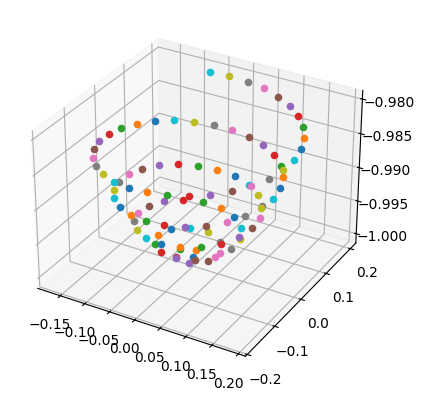

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
#ax = Axes3D(fig)

for ipro in range(100):#range(int(nProj/nSeg)):
    ax.scatter(scale_x[ipro],scale_y[ipro],scale_z[ipro])

plt.show()

# Write real sequence

In [17]:
g_tot_y = copy.deepcopy(g_tot)
g_tot_z = copy.deepcopy(g_tot)
g_tot_y.channel='y'
g_tot_z.channel='z'

In [18]:
seq=pp.Sequence()

ipro = 0
rf_phase = 0
rf_inc = 0
for i in range(nProj + nDummy):
  rf.phase_offset = rf_phase / 180 * np.pi
  rf.phase_offset = rf_phase / 180 * np.pi
  adc.phase_offset = rf_phase / 180 * np.pi
  rf_inc = np.mod(rf_inc + rf_spoiling_inc, 360.0)
  rf_phase = np.mod(rf_phase + rf_inc, 360.0)

  seq.add_block(rf)
  if (i < nDummy):
    seq.add_block(pp.scale_grad(grad = g_tot, scale=scale_x[ipro]),pp.scale_grad(grad = g_tot_y, scale=scale_y[ipro]),pp.scale_grad(grad = g_tot_z, scale=scale_z[ipro]))
  else:
    seq.add_block(adc,pp.scale_grad(grad = g_tot, scale=scale_x[ipro]),pp.scale_grad(grad = g_tot_y, scale=scale_y[ipro]),pp.scale_grad(grad = g_tot_z, scale=scale_z[ipro]))
    ipro = ipro + 1

  seq.add_block(pp.make_delay(delay_TR))

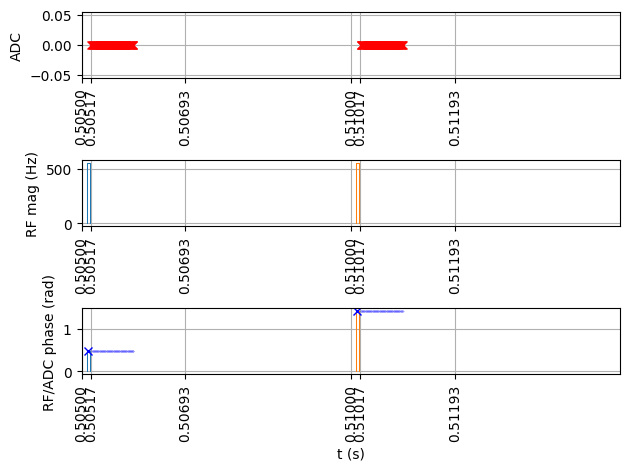

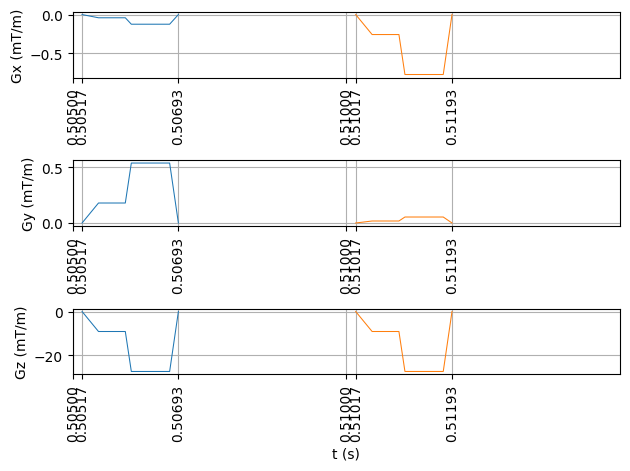

In [19]:
seq.plot(grad_disp="mT/m",show_blocks=True,time_range=(TR*(nDummy+1),TR*(nDummy+3)),time_disp="s",label="SET,PAR")

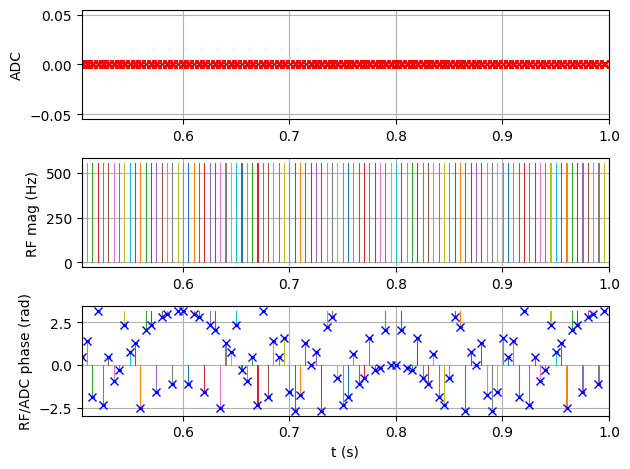

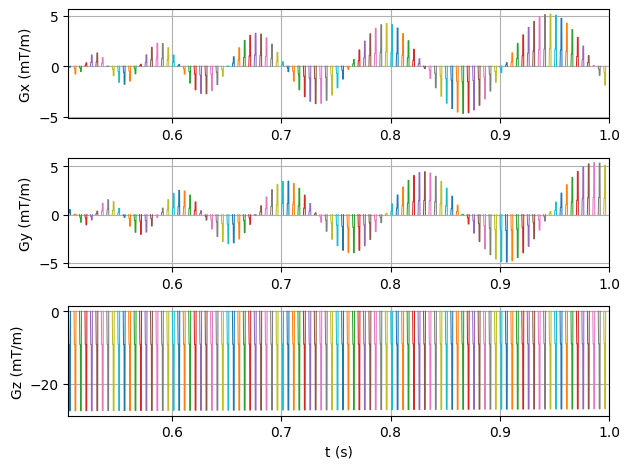

In [20]:
seq.plot(grad_disp="mT/m",show_blocks=False,time_range=(TR*(nDummy+1),TR*(nDummy+100)),time_disp="s",label="SET,PAR")

# Write sequence .seq

In [21]:
seq.check_timing()

(True, [])

## Paramètres à stocker
```
version_sequence = "v1.0.0"
# --------------Paramètres important--------------
fov = np.array([256, 256, 256]) * 1e-3  # Define FOV (m)
N = 128 # size of the reconstruction matrix
alpha=10                     # flip angle
TR = 5e-3                      # TR
nProj= 5000                        # number of radial spokes

# --------------Paramètres divers--------------
threeD = True
riseT = 0.3e-3 #second -> 300us
# attention le dwell time doit être un multiple de 100ns
dwell = 10e-6
nDummy=100                      # number of dummy scans
rf_len = 0.05e-3 # second 
rf_spoiling_inc = 117 # RF spoiling increment
ro_spoil = 3  # Additional k-max excursion for RO spoiling
ro_os = 1  # Readout oversampling
```

In [22]:
seq.set_definition("Name","UTE_"+version_sequence)
seq.set_definition("version_sequence",version_sequence)
# Paramètres système
seq.set_definition("max_grad",system.max_grad)
seq.set_definition("max_slew",system.max_slew)
seq.set_definition("rf_ringdown_time",system.rf_ringdown_time)
seq.set_definition("rf_dead_time",system.rf_dead_time)
seq.set_definition("adc_dead_time",system.adc_dead_time)

# paramètres modifiable
seq.set_definition("FOV",fov)
if threeD:
  N2 = [N,N,N]
else:
  N2 = [N,N]
seq.set_definition("matrix",N2)
seq.set_definition("alpha",alpha)
seq.set_definition("TR",TR*1e3)
seq.set_definition("nProj",nProj)
seq.set_definition("reord_traj",reord_traj)
seq.set_definition("nSegment",nSeg)
seq.set_definition("SGPoints",SGPoints)

## param supp
seq.set_definition("rise_time",riseT)
seq.set_definition("dwell",dwell)
seq.set_definition("nDummy",nDummy)
seq.set_definition("rf_len",rf_len)
seq.set_definition("rf_spoiling_inc",rf_spoiling_inc)
seq.set_definition("ro_spoil",ro_spoil)
seq.set_definition("ro_os",ro_os)

# param faciliter la reco
seq.set_definition("nSample",Ns)
seq.set_definition("3D",threeD)

# Récupération trajectoire
Utilisation `seq.calculate_kspace`
```
k_traj_adc : numpy.array
  K-space trajectory sampled at `t_adc` timepoints.
k_traj : numpy.array
  K-space trajectory of the entire pulse sequence.
t_excitation : List[float]
  Excitation timepoints.
t_refocusing : List[float]
  Refocusing timepoints.
t_adc : numpy.array
  Sampling timepoints.
  ```

In [23]:
#k_traj_adc,k_traj,t_excitation,t_refocusing,t_adc = seq.calculate_kspace()

In [24]:
now = datetime.now()
dt_string = now.strftime("%Y%m%d_%Hh%Mm")
print("date and time =", dt_string)

#seq.write("UTE_"+version_sequence+"_"+dt_string+".seq") # SEQUENCE SANS TRAJ POUR SIEMENS
seq.write("UTE_"+version_sequence+"_"+dt_string+".seq") # SEQUENCE SANS TRAJ POUR SIEMENS

#seq.set_definition("trajx",k_traj_adc[0])
#seq.set_definition("trajy",k_traj_adc[1])
#seq.set_definition("trajz",k_traj_adc[2])
#seq.write("UTE_"+version_sequence+"_"+dt_string+"_traj.seq") # SEQUENCE AVEC TRAJ pour la reco

date and time = 20260206_11h06m


'351878a1052690660768c71d79abdaa0'